# Сравнение классификаторов на синтетических данных

**Цель проекта**: Провести сравнительный анализ различных алгоритмов машинного обучения для задачи бинарной классификации, используя лучшие практики:
* Предотвращение утечки данных (Data Leakage) через Pipeline.
* Оптимизация гиперпараметров через GridSearchCV.
* Оценка качества с помощью коэффициента Джини и визуализация границ решений.

### 1. Генерация и разделение данных
Используем `make_blobs` для создания синтетического набора данных и разделим его на обучающую и тестовую выборки.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

# 1. Генерация данных
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=3.8,
    center_box=(-6.0, 6.0),
    random_state=42
)

# 2. Разделение данных с использованием stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер тренировочной выборки: (700, 2)
Размер тестовой выборки: (300, 2)


### 2. Визуализация и масштабирование
Визуализируем данные и приведем признаки к одному масштабу.

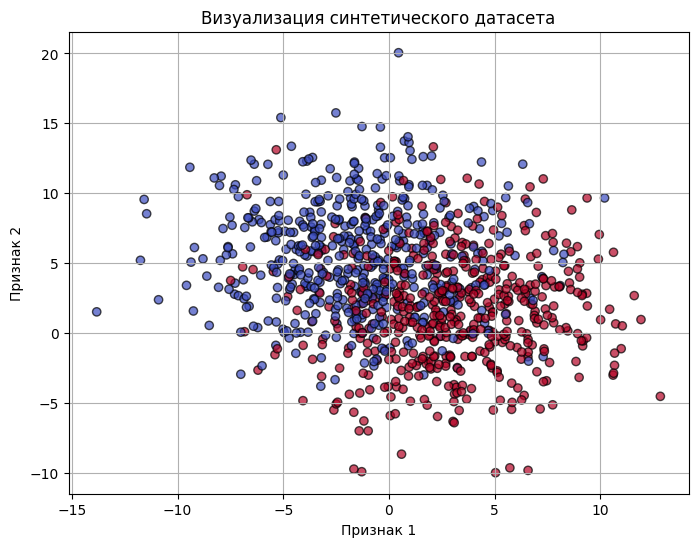

In [7]:
# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title("Визуализация синтетического датасета")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True)
plt.show()

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Поиск гиперпараметров и оценка моделей
Настроим модели и вычислим коэффициент Джини ($Gini = 2 \times AUC - 1$).

In [10]:
# 3. Настройка кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Определение моделей и пайплайнов
# Для линейных моделей и SVM используем Pipeline со StandardScaler
# Для деревьев используем модель напрямую

models_setup = {
    'Logistic Regression': {
        'pipe': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(solver='liblinear'))]),
        'params': {'clf__C': [0.01, 0.1, 1, 10, 100]}
    },
    'SVM': {
        'pipe': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
        'params': {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.01, 0.1, 1]}
    },
    'Decision Tree': {
        'pipe': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
    },
    'Random Forest': {
        'pipe': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
    }
}

results = []

for name, setup in models_setup.items():
    # Поиск по сетке
    grid = GridSearchCV(setup['pipe'], setup['params'], cv=skf, scoring='roc_auc', return_train_score=True)
    grid.fit(X_train, y_train)

    # Метрики
    best_model = grid.best_estimator_
    train_auc = grid.cv_results_['mean_train_score'][grid.best_index_]
    cv_auc = grid.best_score_

    y_prob_test = best_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob_test)
    gini = 2 * test_auc - 1

    results.append({
        'Модель': name,
        'Train AUC': round(train_auc, 4),
        'CV AUC': round(cv_auc, 4),
        'Test AUC': round(test_auc, 4),
        'Gini (Test)': round(gini, 4),
        'Best Params': grid.best_params_
    })

# 5. Вывод сводной таблицы
results_df = pd.DataFrame(results)
display(results_df)

,Модель,Train AUC,CV AUC,Test AUC,Gini (Test),Best Params
0,Logistic Regression,0.8669,0.8649,0.8928,0.7856,{'clf__C': 10}
1,SVM,0.8669,0.8642,0.8925,0.7851,"{'clf__C': 1, 'clf__gamma': 0.01}"
2,Decision Tree,0.8583,0.7998,0.8608,0.7216,"{'max_depth': 3, 'min_samples_split': 2}"
3,Random Forest,0.9291,0.8521,0.8816,0.7632,"{'max_depth': 5, 'n_estimators': 50}"


### 4. Визуальный анализ результатов
Построим границы решений (Decision Boundaries) для лучшей модели, чтобы понять, как алгоритм разделяет пространство признаков.

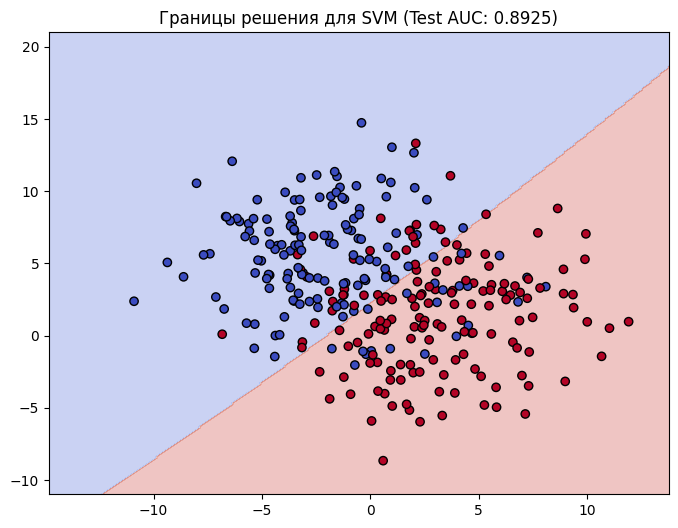

In [11]:
# Визуализация границ решений для лучшей модели (SVM)
best_clf = models_setup['SVM']['pipe'].set_params(**results[1]['Best Params'])
best_clf.fit(X_train, y_train)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = best_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k')
plt.title(f"Границы решения для {results[1]['Модель']} (Test AUC: {results[1]['Test AUC']})")
plt.show()

## Выводы
В ходе эксперимента было установлено, что:
1. **Линейные модели** (Логистическая регрессия и SVM) демонстрируют наилучшую обобщающую способность на данных с сильным перекрытием.
2. **Ансамбли** (Random Forest) склонны к переобучению при малом количестве признаков без жесткого ограничения глубины.
3. Использование **Pipelines** гарантирует корректность масштабирования данных при кросс-валидации.